In [146]:
import time,json,os
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from tqdm.notebook import tqdm_notebook
from common import preprocess,get_csv_files
from warnings import filterwarnings
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance
from scipy.stats import stats
from scipy.spatial.distance import pdist
from sklearn.metrics.pairwise import cosine_similarity
filterwarnings("ignore") 
np.set_printoptions(suppress=True)
pd.set_option('display.float_format',lambda x : '%.8f' % x)
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [252]:
def show_heatmap(df):
    plt.style.use({'figure.figsize':(16, 6)})
    plt.ticklabel_format(style='plain',axis='both')
    sns.set(font_scale=1.5)
    cmap = sns.cubehelix_palette(start = 1, rot = 3, gamma=0.8, as_cmap = True)
    sns.heatmap(df, cmap = cmap, linewidths = 0.05,annot=False, fmt="g",annot_kws={"fontsize":32})
    #plt.xticks(rotation=60)
    #plt.yticks(rotation=60)
    #font2 = {'family': 'Times New Roman','weight': 'normal','size': 24}
    #plt.xlabel('G2', font2)
    #plt.ylabel('G1', font2)

In [190]:
def get_histogram(df , with_preprocess = True):
    if with_preprocess:
        df_tmp = preprocess(df)
    else:
        df_tmp = df.copy( deep = True )
    del df_tmp['label']
    ret_df = pd.DataFrame()
    ret_series = pd.Series()
    for key in df_tmp.keys():
        #hist, bin_edges = np.histogram(df_tmp[key],bins=15*len(df.keys()), density=True)
        hist, bin_edges = np.histogram( df_tmp[key] ,5 * len(df_tmp.keys()) )
        ret_df[key] = pd.Series(hist)
        #cate = pd.qcut( ret_df[key],10,labels=False,duplicates='drop',precision=8)
        #cate.fillna(-1,inplace=True)
        #ret_df[key] = cate
        ret_df[key] = ( ret_df[key] - ret_df[key].min() ) / ( ret_df[key].max()-ret_df[key].min() ) 
        #ret_df[key] = (ret_df[key] - ret_df[key].mean())/ ret_df[key].std()
        #ret_df[key].fillna(-1,inplace=True)
        ret_series = ret_series.append(ret_df[key], ignore_index=True)

    return ret_df.T,ret_series.reset_index(drop=True)

In [191]:
class CJSimilarity(object):
    def __init__(self,list1,list2):
        self.m_list1 = list1
        self.m_list2 = list2
    
    #余弦距离（cosine）
    def Cosine(self):
        ret = cosine_similarity([self.m_list1, self.m_list2])
        return ret[0][1]
        return cosine(self.m_list1, self.m_list2)
    
    #皮尔森相关系数（pearson）,https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
    def Pearson(self):
        return stats.pearsonr(self.m_list1, self.m_list2)[0]
    
    #欧式距离
    def Euclidean(self):
        return np.linalg.norm(np.array(self.m_list1) - np.array(self.m_list2))

    #KS检验,(P越大，两个分布越相似)
    #P比指定的显著水平（假设为5%）小，则我们完全可以拒绝假设，即两个分布不服从同一分布。
    def KSTest(self):
        ret = ks_2samp(self.m_list1, self.m_list2)
        return ret[0],ret[1]
    
    #EDM距离
    def EDM(self):
        return wasserstein_distance(self.m_list1, self.m_list2)
    
    #Manhattan
    def Manhattan(self):
        return sum(abs(a-b) for a,b in zip(self.m_list1,self.m_list2))
    
    #Minkowski
    def Minkowski(self):
        return float(self.minkowski_distance(np.array(self.m_list1),np.array(self.m_list2),3))
    
    #Jaccard
    def Jaccard(self):
        return self.jaccard_similarity(self.m_list1,self.m_list2)
    
    def minkowski_distance(self,x,y,p_value):
        return self.nth_root(sum(pow(abs(a-b),p_value) for a,b in zip(x, y)),p_value)
    
    def nth_root(self,value, n_root):
        root_value = 1/float(n_root)
        return round (float(value) ** float(root_value),3)
    
    def jaccard_similarity(self,x,y):
        intersection_cardinality = len(set.intersection(*[set(x), set(y)]))
        union_cardinality = len(set.union(*[set(x), set(y)]))
        return intersection_cardinality/float(union_cardinality)
    
    #def Quadratic(self):
    #    return get_quadratic_distance(self.m_list1,self.m_list2)

In [192]:
csv_list = []
get_csv_files("/data/paper/sample/",csv_list)
csv_list.sort()
train_hist = {}
test_hist = {}
print("Calculating histogram...")
bar = tqdm(total=len(csv_list))
for fi in csv_list:
    dataset = os.path.splitext(os.path.basename(fi))[0]
    df = pd.read_csv(fi,index_col=0)
    df_hist,ds_hist = get_histogram(df)
    test_hist[dataset] = {}
    test_hist[dataset]['df_hist'] = df_hist
    test_hist[dataset]['ds_hist'] = ds_hist
    if dataset.split("-")[-1] != '0':
        bar.update(1)
        continue
    train_hist[dataset] = {}
    train_hist[dataset]['df_hist'] = df_hist
    train_hist[dataset]['ds_hist'] = ds_hist
    bar.update(1)

Calculating histogram...


  0%|          | 0/64 [00:00<?, ?it/s]

In [193]:
pd.set_option('display.float_format',lambda x : '%.2f' % x)
df_hist.T

,duration,missed_bytes,src_port,dst_port,src_bytes,dst_bytes,src_pkts,dst_pkts,dst_ip_bytes,conn_state_OTH,...,service_gssapi,service_http,service_irc,service_smb,service_smb;gssapi,service_ssh,service_ssl,proto_icmp,proto_tcp,proto_udp
0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.40,1.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
181,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
182,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
183,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [219]:
all_similarity = []
print("Calculating distance ...")
bar = tqdm(total=len(train_hist))
for d1 in train_hist:
    for d2 in test_hist:
        s = CJSimilarity(train_hist[d1]['ds_hist'].tolist(),test_hist[d2]['ds_hist'].tolist())
        tmp = {}
        tmp['G1'] = d1[0:3]
        tmp['G2'] = d2[0:3]
        tmp['D1'] = d1
        tmp['D2'] = d2
        tmp['Cosine'] = s.Cosine()
        tmp['Pearson'] = s.Pearson()
        tmp['Euclidean'] = s.Euclidean()
        tmp['EDM'] = s.EDM()
        tmp['KS'] = s.KSTest()[1]
        tmp['Manhattan'] = s.Manhattan()
        tmp['Minkowski'] = s.Minkowski()
        tmp['Jaccard'] = s.Jaccard()
        #tmp['Qaccard'] = s.Quadratic()

        all_similarity.append(tmp)
    bar.update( 1 )
df_similarity = pd.DataFrame(all_similarity)
df_similarity.to_csv("/data/paper/analyse/similarity.csv")

Calculating distance ...


  0%|          | 0/16 [00:00<?, ?it/s]

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.000410,0.001277,0.001621,0.001819
s-1,0.001214,0.000280,0.000612,0.000731
s-2,0.001605,0.000568,0.000024,0.000268
s-3,0.001803,0.000684,0.000273,0.000181


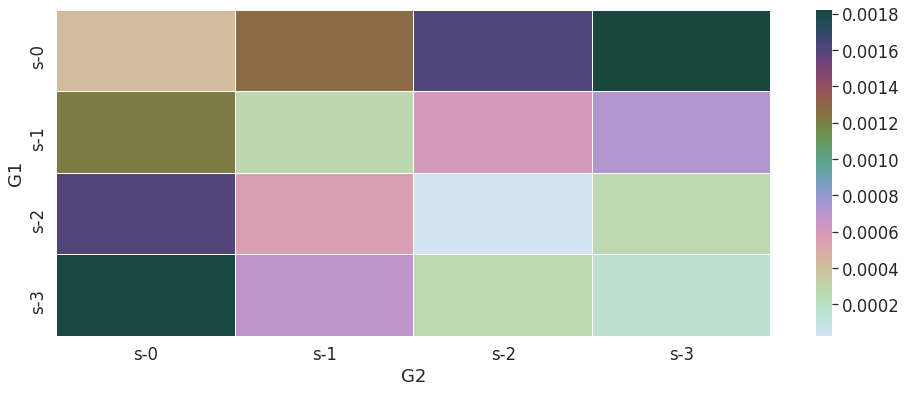

In [259]:
pd.set_option('display.float_format',lambda x : '%.6f' % x)
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='EDM',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.571775,6.224925,4.691204,4.553288
s-1,6.235705,2.730272,4.202124,4.336931
s-2,4.655588,4.227994,1.209546,1.351094
s-3,4.554954,4.300423,1.425360,1.358542


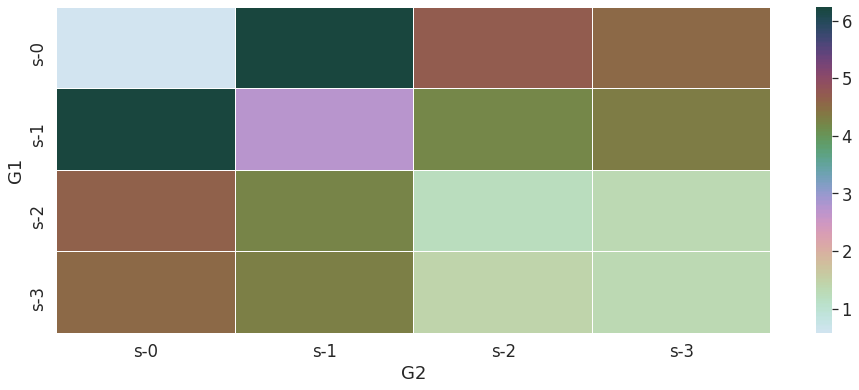

In [260]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Euclidean',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.994214,0.535995,0.732775,0.747487
s-1,0.536058,0.897300,0.777680,0.762149
s-2,0.736541,0.770033,0.970987,0.969763
s-3,0.746803,0.761477,0.967350,0.970205


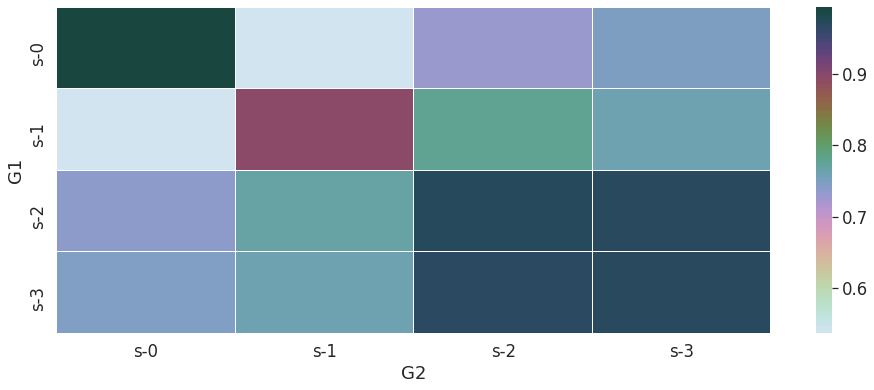

In [261]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Cosine',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.994155,0.531507,0.730342,0.745292
s-1,0.531549,0.896416,0.775831,0.760238
s-2,0.734148,0.768130,0.970754,0.969531
s-3,0.744607,0.759570,0.967099,0.969981


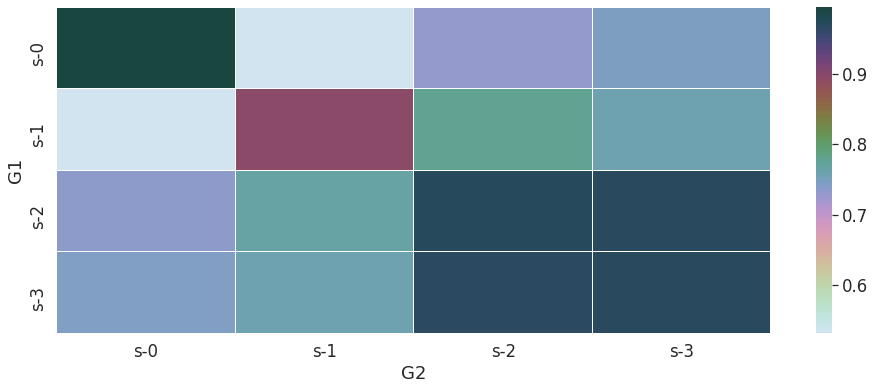

In [262]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Pearson',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,3.300442,60.697752,42.072127,39.342076
s-1,60.835671,11.102879,23.895796,26.238119
s-2,41.686855,24.190256,2.580488,4.730261
s-3,39.293529,25.966644,4.899205,3.871796


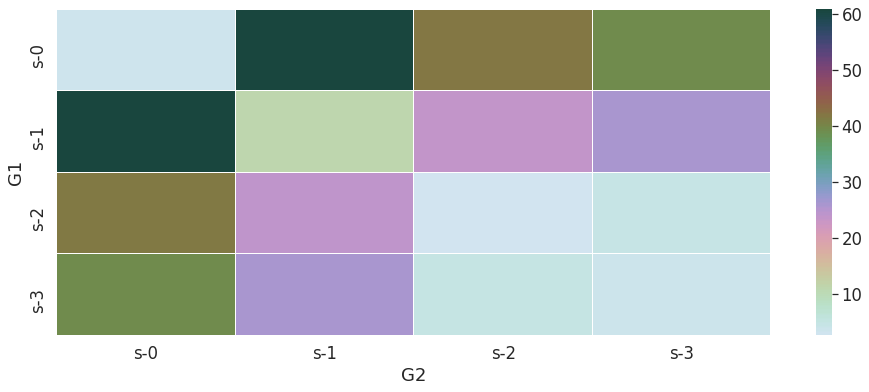

In [263]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Manhattan',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.405922,3.243547,2.642781,2.598859
s-1,3.246781,1.856359,2.541219,2.579359
s-2,2.626656,2.549359,0.983750,1.062453
s-3,2.598969,2.561250,1.130938,1.118937


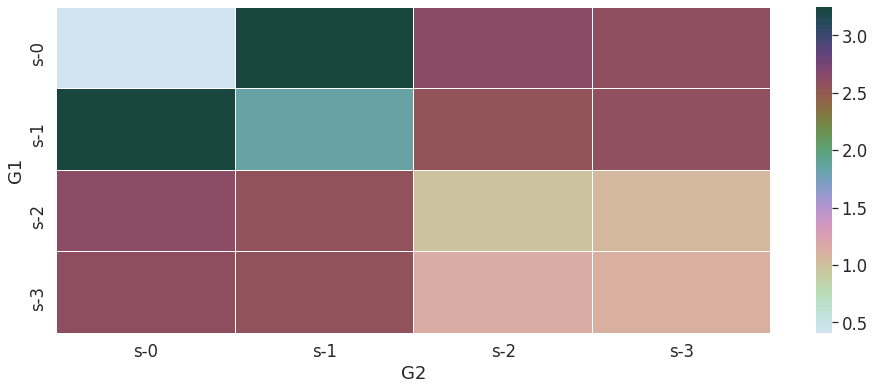

In [264]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Minkowski',aggfunc=np.mean)
show_heatmap(pt)
pt

G2,s-0,s-1,s-2,s-3
G1,,,,
s-0,0.067216,0.004329,0.005094,0.004491
s-1,0.004503,0.072749,0.006911,0.007111
s-2,0.004850,0.006572,0.069781,0.007173
s-3,0.004676,0.007560,0.006931,0.069106


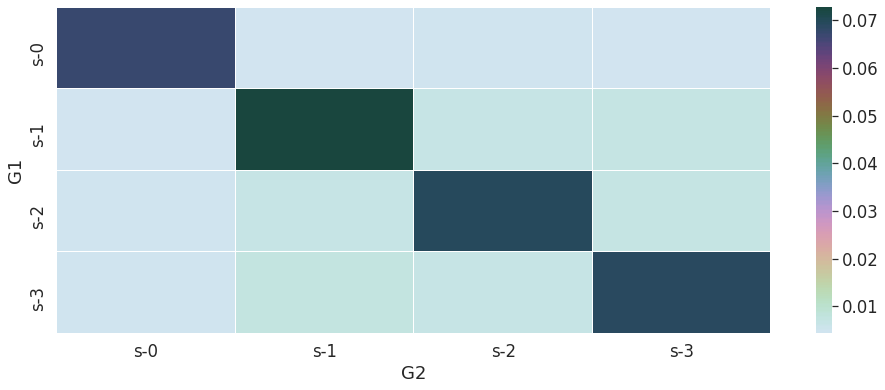

In [267]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='Jaccard',aggfunc=np.mean)
show_heatmap(pt)
pt

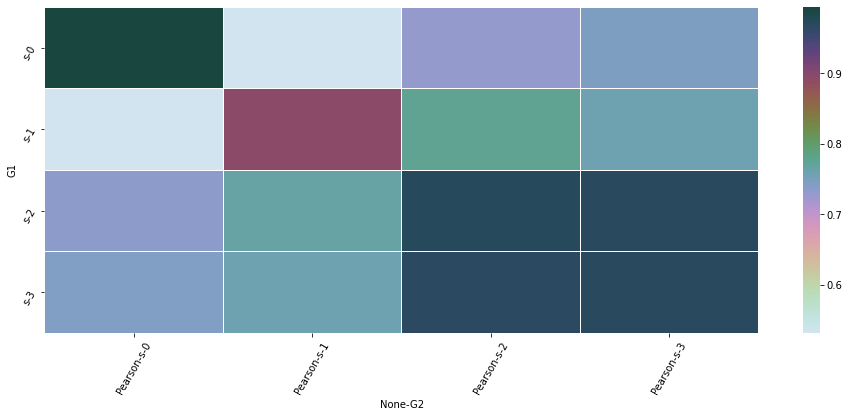

In [212]:
pt = df_similarity.pivot_table(index='G1', columns=['G2'],  values=['Pearson'],aggfunc=np.mean)
show_heatmap(pt)

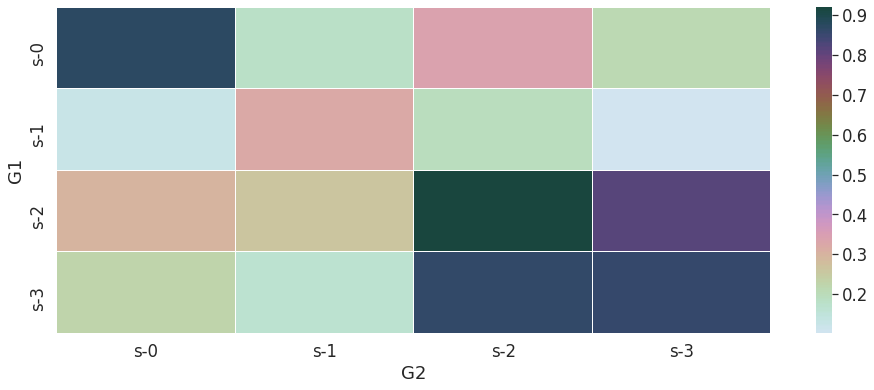

In [265]:
pt = df_similarity.pivot_table(index='G1', columns='G2',  values='KS',aggfunc=np.mean)
show_heatmap(pt)

In [268]:
df = pd.read_csv("/data/paper/analyse/cnn.csv",index_col=0)
df = df[(df['train']=='s-0-1-0')]
del df['confusion_matrix']
del df['roc_curve']
del df['train']

In [269]:
df

,recall,mcc,accuracy,precision,auc,log_loss,f1_score,fbeta_score,model,valid
128,0.891911,0.882442,0.955708,0.932152,0.934786,1.529805,0.911588,0.923816,cnn,s-0-1-0
129,0.889496,0.881000,0.958260,0.926545,0.934182,1.441662,0.907643,0.918890,cnn,s-0-1-1
130,0.891741,0.883220,0.956112,0.933267,0.934950,1.515851,0.912031,0.924655,cnn,s-0-1-2
131,0.884263,0.877056,0.944390,0.953329,0.930493,1.920713,0.917498,0.938666,cnn,s-0-1-3
132,0.889761,0.880955,0.955120,0.932132,0.933710,1.550114,0.910453,0.923338,cnn,s-0-2-0
...,...,...,...,...,...,...,...,...,...,...
187,0.557481,0.032406,0.503754,0.348457,0.517134,17.140008,0.428855,0.376706,cnn,s-3-3-3
188,0.559185,0.034221,0.512352,0.458367,0.517169,16.842999,0.503781,0.475513,cnn,s-3-4-0
189,0.567849,-0.063037,0.466820,0.462683,0.469103,18.415642,0.509900,0.480480,cnn,s-3-4-1
190,0.565119,0.038675,0.514040,0.459010,0.519398,16.784699,0.506567,0.476920,cnn,s-3-4-2
